<div style="background-color:#0D2741;background-image:linear-gradient(90deg,#0D2741,#1d4063);color:#ffffff;padding:24px 28px;border-radius:8px;">
<div style="font-size:12.5px;letter-spacing:1.5px;color:#aac4dd;">UNIVERSIDAD ANDRÉS BELLO · MAGÍSTER EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL</div>
<div style="font-size:27px;font-weight:700;margin-top:8px;line-height:1.15;">Intervalos de Confianza</div>
<div style="font-size:17px;color:#d7e3ef;margin-top:2px;">Cuantificando la incertidumbre estadística</div>
<div style="margin-top:12px;font-size:12.5px;color:#aac4dd;">Maidana, J.P. · 2026 · Apunte de cátedra</div>
</div>


In [1]:
import numpy as np
import scipy
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

# Paleta institucional UNAB
UNAB_NAVY = "#0D2741"
UNAB_RED  = "#AE0000"
VERDE     = "#2E8B57"
NARANJA   = "#E08600"
MORADO    = "#7E57C2"

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

print(f"numpy {np.__version__} · scipy {scipy.__version__} · matplotlib {mpl.__version__}")


numpy 2.4.4 · scipy 1.17.1 · matplotlib 3.10.8


## 1. Introducción

> *"En ciencia de datos rara vez trabajamos con certezas absolutas. Cada estimación que calculamos viene acompañada de incertidumbre."*

### 1.1 El problema de la estimación puntual

Imagina dos analistas que reportan el ingreso promedio de los clientes:

| | |
|:--|:--|
| **Analista A** | "El ingreso promedio es \$45,000." |
| **Analista B** | "El ingreso promedio es \$45,000 (IC 95%: [\$42,500, \$47,500])." |

La respuesta del Analista B es más profesional y útil: no solo entrega una estimación, sino que **cuantifica la incertidumbre** inherente a trabajar con muestras.


<div style="background:#fdf4e7;border-left:5px solid #E08600;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#9a5b00;">Pregunta central</strong><br><br>
<em>¿Cómo transformar una estimación puntual (un solo número) en un rango de valores plausibles que capture nuestra incertidumbre, comunicando tanto la mejor estimación como qué tan seguros estamos de ella?</em>
</div>


### 1.2 El ecosistema de los intervalos de confianza

El recorrido va desde la muestra hasta la inferencia sobre el parámetro poblacional. La figura siguiente resume las cuatro etapas y sus componentes.


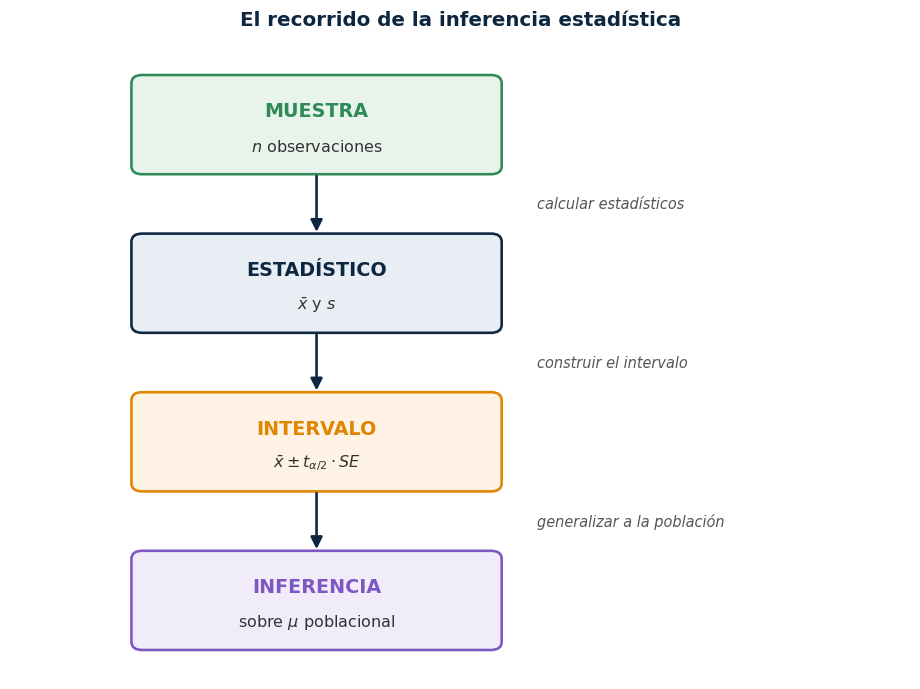

In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(8.5, 6.4))
ax.set_xlim(0, 10)
ax.set_ylim(0.2, 9.6)
ax.axis("off")

etapas = [
    ("MUESTRA",      r"$n$ observaciones",                  "#e8f3ec", VERDE),
    ("ESTADÍSTICO",  r"$\bar{x}$ y $s$",                    "#e9eef5", UNAB_NAVY),
    ("INTERVALO",    r"$\bar{x}\pm t_{\alpha/2}\cdot SE$",  "#fdf2e3", NARANJA),
    ("INFERENCIA",   r"sobre $\mu$ poblacional",            "#f1ecfa", MORADO),
]
acciones = ["calcular estadísticos", "construir el intervalo", "generalizar a la población"]

xc, bw, bh = 3.4, 4.0, 1.35
y_top, dy = 8.4, 2.35
centros = []
for i, (titulo, sub, bg, borde) in enumerate(etapas):
    y = y_top - i*dy
    ax.add_patch(FancyBboxPatch((xc-bw/2, y-bh/2), bw, bh,
                 boxstyle="round,pad=0.06,rounding_size=0.12",
                 linewidth=1.7, edgecolor=borde, facecolor=bg))
    ax.text(xc, y+0.20, titulo, ha="center", va="center",
            fontsize=12.5, fontweight="bold", color=borde)
    ax.text(xc, y-0.32, sub, ha="center", va="center", fontsize=10.5, color="#333333")
    centros.append((xc, y))

for i in range(len(etapas)-1):
    x0, y0 = centros[i]
    x1, y1 = centros[i+1]
    ax.add_patch(FancyArrowPatch((x0, y0-bh/2-0.04), (x1, y1+bh/2+0.04),
                 arrowstyle="-|>", mutation_scale=16, linewidth=1.7, color=UNAB_NAVY))
    ax.text(xc+bw/2+0.45, (y0+y1)/2, acciones[i], ha="left", va="center",
            fontsize=9.5, style="italic", color="#555555")

ax.set_title("El recorrido de la inferencia estadística", pad=12,
             fontsize=13, fontweight="bold", color=UNAB_NAVY)
plt.tight_layout()
plt.show()


<div style="background:#fbf8e8;border-left:5px solid #C9A400;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#7d6500;">Objetivos de aprendizaje</strong>
<ol style="margin:8px 0 0 0;">
<li>Comprender qué es un IC y cuál es su interpretación correcta.</li>
<li>Distinguir el caso de $\sigma$ conocida (Z) del de $\sigma$ desconocida (t).</li>
<li>Dominar la distribución t de Student y sus propiedades.</li>
<li>Construir ICs manualmente y con <code>scipy.stats</code>.</li>
<li>Interpretar correctamente los ICs evitando los errores habituales.</li>
<li>Aplicar ICs a problemas reales de toma de decisiones.</li>
<li>Visualizar y comunicar la incertidumbre de forma efectiva.</li>
</ol>
</div>


## 2. Fundamentos conceptuales

### 2.1 Definición formal

<div style="background:#eef3fb;border-left:5px solid #2563AE;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#1b4f87;">Definición</strong><br><br>
Un <strong>intervalo de confianza</strong> (IC) al nivel $(1-\alpha)\times 100\%$ para un parámetro $\theta$ es un rango $[L, U]$ calculado a partir de los datos muestrales tal que
$$P(L \le \theta \le U) = 1 - \alpha.$$
<strong>Estructura general para la media:</strong>
$$IC = \text{Estimador} \;\pm\; \underbrace{\text{Valor crítico}}_{z_{\alpha/2}\ \text{o}\ t_{\alpha/2,\,df}}\times \underbrace{\text{Error estándar}}_{\sigma/\sqrt{n}\ \text{o}\ s/\sqrt{n}}$$
donde $ME = \text{Valor crítico}\times SE$ es el <strong>margen de error</strong>.
</div>


### 2.2 Visualización del concepto

La idea clave es que el parámetro $\mu$ es fijo y desconocido, mientras que el intervalo cambia con cada muestra. Si construimos muchos intervalos al 95%, alrededor del 95% de ellos contendrá $\mu$. La simulación siguiente lo muestra de forma explícita.


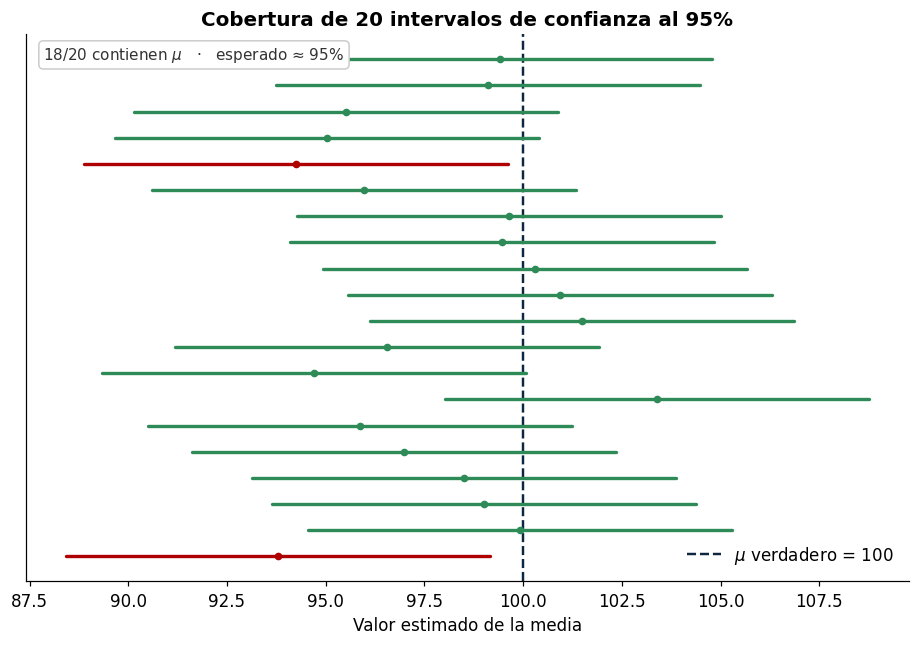

In [3]:
rng = np.random.default_rng(7)
mu_true, sigma_true, n = 100.0, 15.0, 30
n_intervalos, conf = 20, 0.95
z = stats.norm.ppf(1 - (1 - conf)/2)

fig, ax = plt.subplots(figsize=(8.5, 6))
cubre = 0
for i in range(n_intervalos):
    muestra = rng.normal(mu_true, sigma_true, n)
    m  = muestra.mean()
    se = sigma_true / np.sqrt(n)          # sigma conocida (solo para ilustrar)
    lo, hi = m - z*se, m + z*se
    contiene = lo <= mu_true <= hi
    cubre += contiene
    color = VERDE if contiene else UNAB_RED
    ax.plot([lo, hi], [i, i], color=color, lw=2.2, solid_capstyle="round", zorder=2)
    ax.plot(m, i, "o", color=color, ms=4, zorder=3)

ax.axvline(mu_true, color=UNAB_NAVY, ls="--", lw=1.6, zorder=1,
           label=r"$\mu$ verdadero = %g" % mu_true)
ax.set_yticks([])
ax.set_xlabel("Valor estimado de la media")
ax.set_title(f"Cobertura de {n_intervalos} intervalos de confianza al {int(conf*100)}%")
ax.legend(loc="lower right")
ax.text(0.02, 0.98,
        f"{cubre}/{n_intervalos} contienen " + r"$\mu$" + f"   ·   esperado \u2248 {int(conf*100)}%",
        transform=ax.transAxes, va="top", fontsize=10, color="#333333",
        bbox=dict(boxstyle="round", fc="white", ec="#cccccc"))
plt.tight_layout()
plt.show()


### 2.3 Interpretación: correcta vs incorrecta

<div style="background:#fdf4e7;border-left:5px solid #E08600;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#9a5b00;">Interpretación correcta (frecuentista)</strong><br><br>
<em>"Si repitiéramos el proceso de muestreo y construcción del IC muchas veces, aproximadamente el 95% de esos intervalos contendrían el verdadero parámetro $\mu$."</em><br><br>
<strong>Conceptos clave:</strong> el parámetro $\mu$ es <strong>fijo</strong>; el intervalo $[L,U]$ es <strong>aleatorio</strong> (cambia de muestra en muestra); la confianza se refiere al <strong>procedimiento</strong>, no a un intervalo concreto.<br><br>
<strong>Forma práctica aceptable:</strong> "estamos 95% confiados de que $\mu$ está entre $[L,U]$" — técnicamente imprecisa, pero estándar en los informes.
</div>

<div style="background:#fbeeec;border-left:5px solid #C0392B;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#8e2a20;">Interpretaciones incorrectas</strong>
<ul style="margin:8px 0 0 0;">
<li>✗ "Hay 95% de probabilidad de que $\mu$ esté en $[L,U]$" — $\mu$ no es aleatorio; confunde la visión frecuentista con la bayesiana.</li>
<li>✗ "95% de los datos están en este intervalo" — el IC es para el <strong>parámetro</strong>, no para datos individuales.</li>
<li>✗ "Estamos 95% seguros de que la muestra es representativa" — el IC <strong>asume</strong> muestreo aleatorio; no lo valida.</li>
<li>✗ "El verdadero valor está definitivamente en $[L,U]$" — existe un 5% de probabilidad de que no lo esté.</li>
</ul>
</div>


### 2.4 Niveles de confianza comunes

| Confianza | $\alpha$ | $\alpha/2$ | $z_{\alpha/2}$ | $t_{\alpha/2}$ ($df=20$) |
|:--:|:--:|:--:|:--:|:--:|
| 80% | 0.20 | 0.10 | 1.282 | 1.325 |
| 90% | 0.10 | 0.05 | 1.645 | 1.725 |
| **95%** | **0.05** | **0.025** | **1.960** | **2.086** |
| 99% | 0.01 | 0.005 | 2.576 | 2.845 |
| 99.9% | 0.001 | 0.0005 | 3.291 | 3.850 |

**Trade-off confianza vs precisión:** una mayor confianza (99% frente a 95%) produce un IC más ancho (menos preciso); una menor confianza, un IC más estrecho. La elección depende del contexto y del costo de los errores.


## 3. Caso 1: IC con $\sigma$ conocida (distribución normal)

### 3.1 Fundamentos teóricos

<div style="background:#eef3fb;border-left:5px solid #2563AE;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#1b4f87;">Definición</strong><br><br>
<strong>Supuestos:</strong> muestra aleatoria de tamaño $n$; varianza poblacional $\sigma^2$ <strong>conocida</strong>; población normal o $n \ge 30$ (TLC).<br><br>
<strong>Estadístico pivote:</strong> por el TLC, $\displaystyle Z = \frac{\bar{X}-\mu}{\sigma/\sqrt{n}} \sim N(0,1)$.<br><br>
<strong>Intervalo al $(1-\alpha)\times 100\%$:</strong>
$$IC_{1-\alpha} = \bar{x} \pm z_{\alpha/2}\cdot \frac{\sigma}{\sqrt{n}}$$
con $\bar{x}$ la estimación puntual, $z_{\alpha/2}$ el valor crítico de $N(0,1)$, $\sigma/\sqrt{n}$ el error estándar y $ME = z_{\alpha/2}\times SE$ el margen de error.
</div>

<div style="background:#f3eefb;border-left:5px solid #7E57C2;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#5331a0;">Teorema — derivación del intervalo</strong><br><br>
Partiendo del estadístico estandarizado,
$$P\!\left(-z_{\alpha/2} \le \frac{\bar{X}-\mu}{\sigma/\sqrt{n}} \le z_{\alpha/2}\right) = 1-\alpha.$$
Despejando $\mu$ (multiplicando por $\sigma/\sqrt{n}$ y sumando $\bar{X}$):
$$IC = \left[\,\bar{X} - z_{\alpha/2}\frac{\sigma}{\sqrt{n}},\ \ \bar{X} + z_{\alpha/2}\frac{\sigma}{\sqrt{n}}\,\right].$$
</div>


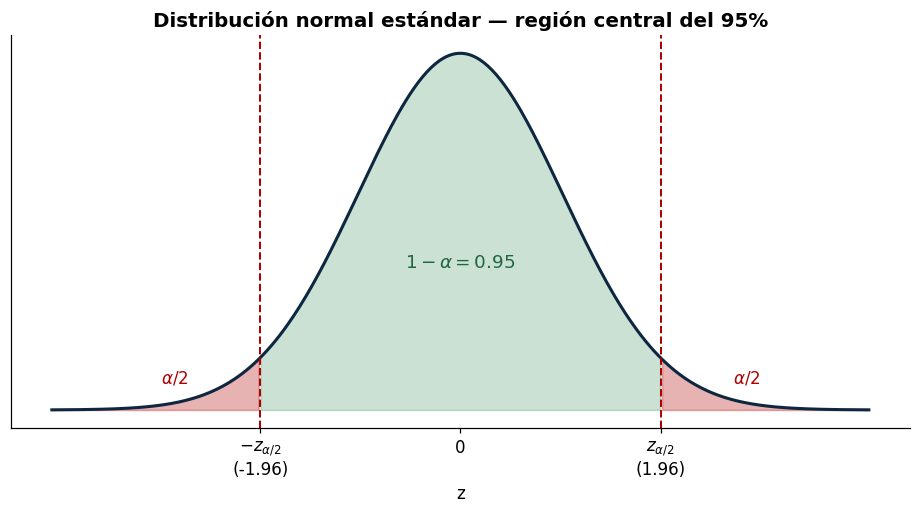

In [4]:
x  = np.linspace(-4, 4, 400)
y  = stats.norm.pdf(x)
zc = stats.norm.ppf(0.975)            # 1.96

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(x, y, color=UNAB_NAVY, lw=2)
m = (x >= -zc) & (x <= zc)
ax.fill_between(x[m], y[m], color=VERDE, alpha=0.25)
ax.fill_between(x[x <= -zc], y[x <= -zc], color=UNAB_RED, alpha=0.30)
ax.fill_between(x[x >=  zc], y[x >=  zc], color=UNAB_RED, alpha=0.30)
for s in (-zc, zc):
    ax.axvline(s, color=UNAB_RED, ls="--", lw=1.3)

ax.set_xticks([-zc, 0, zc])
ax.set_xticklabels([r"$-z_{\alpha/2}$" + f"\n({-zc:.2f})", "0",
                    r"$z_{\alpha/2}$" + f"\n({zc:.2f})"])
ax.set_yticks([])
ax.set_xlabel("z")
ax.text(0, 0.16, r"$1-\alpha = 0.95$", ha="center", fontsize=12,
        color="#20663f", fontweight="bold")
ax.text(-2.8, 0.03, r"$\alpha/2$", ha="center", color=UNAB_RED, fontsize=11)
ax.text( 2.8, 0.03, r"$\alpha/2$", ha="center", color=UNAB_RED, fontsize=11)
ax.set_title("Distribución normal estándar — región central del 95%")
plt.tight_layout()
plt.show()


### 3.2 Ejemplo completo

<div style="background:#eef7f0;border-left:5px solid #2E8B57;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#20663f;">Ejemplo — Control de calidad: peso de paquetes</strong><br><br>
<strong>Datos:</strong> $n=50$, $\bar{x}=502.3$ g, $\sigma=15$ g (conocida), confianza $95\%$.<br><br>
<strong>Paso 1.</strong> $SE = \sigma/\sqrt{n} = 15/\sqrt{50} = 2.121$ g.<br>
<strong>Paso 2.</strong> $\alpha = 0.05 \Rightarrow z_{0.025} = 1.96$.<br>
<strong>Paso 3.</strong> $ME = 1.96 \times 2.121 = 4.157$ g.<br>
<strong>Paso 4.</strong> $IC_{95\%} = 502.3 \pm 4.157 = [498.14,\ 506.46]$ g.<br><br>
<strong>Interpretación:</strong> estamos 95% confiados de que el peso medio está entre 498.14 y 506.46 g. Si la especificación es $500 \pm 10$ g, el IC completo cae dentro del rango → proceso bajo control.
</div>

El cálculo se reproduce con código en la sección 7.1.


## 4. Caso 2: IC con $\sigma$ desconocida (distribución t)

### 4.1 La distribución t de Student

<div style="background:#eef3fb;border-left:5px solid #2563AE;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#1b4f87;">Definición</strong><br><br>
Cuando $\sigma$ es <strong>desconocida</strong> (el caso realista) se estima con $s$, lo que introduce incertidumbre adicional. El estadístico pivote es
$$T = \frac{\bar{X}-\mu}{s/\sqrt{n}} \sim t_{n-1}.$$
<strong>Propiedades:</strong> simétrica en torno a 0; colas más pesadas que $N(0,1)$; converge a $N(0,1)$ cuando $df \to \infty$; más ancha para $df$ pequeños (refleja mayor incertidumbre).<br><br>
<strong>Intuición:</strong> al estimar $\sigma$ con $s$ hay más incertidumbre → se necesitan intervalos más anchos → colas más pesadas.<br><br>
<strong>Intervalo de confianza:</strong>
$$IC_{1-\alpha} = \bar{x} \pm t_{\alpha/2,\,n-1}\cdot \frac{s}{\sqrt{n}}.$$
</div>


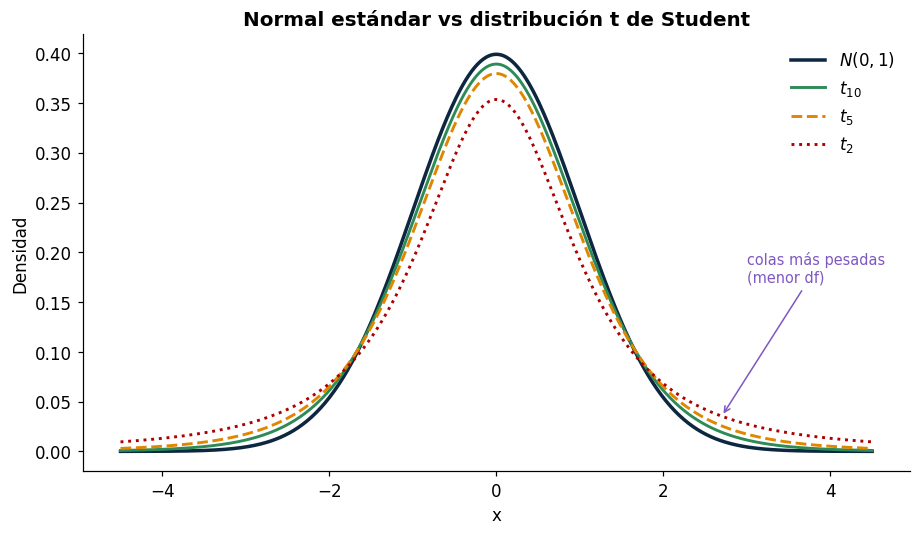

In [5]:
x = np.linspace(-4.5, 4.5, 500)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(x, stats.norm.pdf(x), color=UNAB_NAVY, lw=2.3, label=r"$N(0,1)$")
for df, col, ls in [(10, VERDE, "-"), (5, NARANJA, "--"), (2, UNAB_RED, ":")]:
    ax.plot(x, stats.t.pdf(x, df), color=col, lw=1.9, ls=ls, label=fr"$t_{{{df}}}$")

ax.set_title("Normal estándar vs distribución t de Student")
ax.set_xlabel("x")
ax.set_ylabel("Densidad")
ax.legend()
ax.annotate("colas más pesadas\n(menor df)", xy=(2.7, stats.t.pdf(2.7, 2)),
            xytext=(3.0, 0.17), fontsize=9.5, color=MORADO,
            arrowprops=dict(arrowstyle="->", color=MORADO))
plt.tight_layout()
plt.show()


### 4.2 Tabla de valores críticos de t (dos colas)

| df | 80% | 90% | 95% | 98% | 99% |
|:--:|:--:|:--:|:--:|:--:|:--:|
| 1 | 3.078 | 6.314 | **12.706** | 31.821 | 63.657 |
| 5 | 1.476 | 2.015 | **2.571** | 3.365 | 4.032 |
| 10 | 1.372 | 1.812 | **2.228** | 2.764 | 3.169 |
| 15 | 1.341 | 1.753 | **2.131** | 2.602 | 2.947 |
| 20 | 1.325 | 1.725 | **2.086** | 2.528 | 2.845 |
| 30 | 1.310 | 1.697 | **2.042** | 2.457 | 2.750 |
| 100 | 1.290 | 1.660 | **1.984** | 2.364 | 2.626 |
| $\infty$ (Z) | 1.282 | 1.645 | 1.960 | 2.326 | 2.576 |

Para $df=5$ y 95%, $t_{0.025}=2.571 \gt 1.96$. Para $df=100$, $t_{0.025}=1.984 \approx 1.96$. La diferencia es más marcada con muestras pequeñas.


### 4.3 Ejemplo completo con la distribución t

<div style="background:#eef7f0;border-left:5px solid #2E8B57;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#20663f;">Ejemplo — Estudio clínico: reducción de presión arterial</strong><br><br>
<strong>Datos:</strong> $n=12$, $\bar{x}=8.5$ mmHg, $s=3.2$ mmHg ($\sigma$ desconocida), confianza $95\%$.<br><br>
<strong>Paso 1.</strong> $df = 11$.<br>
<strong>Paso 2.</strong> $SE = 3.2/\sqrt{12} = 0.924$ mmHg.<br>
<strong>Paso 3.</strong> $t_{0.025,\,11} = 2.201$.<br>
<strong>Paso 4.</strong> $ME = 2.201 \times 0.924 = 2.034$ mmHg.<br>
<strong>Paso 5.</strong> $IC_{95\%} = 8.5 \pm 2.034 = [6.47,\ 10.53]$ mmHg.<br><br>
<strong>Comparación con Z (incorrecto):</strong> $ME_Z = 1.96 \times 0.924 = 1.811 \Rightarrow IC_Z = [6.69,\ 10.31]$. El IC con $t$ es $\approx 12\%$ más ancho, lo correcto para esta muestra pequeña.<br><br>
<strong>Decisión clínica:</strong> como todo el IC supera los 5 mmHg (umbral clínicamente significativo), el tratamiento parece efectivo.
</div>

El cálculo, junto con la comparación t vs Z, se reproduce en la sección 7.2.


## 5. ¿Cuándo usar Z vs t?

| Condición | Distribución | Cuándo |
|:--|:--|:--|
| $\sigma$ conocida | Normal ($Z$) | Varianza establecida históricamente (muy raro) |
| $\sigma$ desconocida, $n \lt 30$ | t de Student | Siempre; las colas pesadas compensan la incertidumbre |
| $\sigma$ desconocida, $n \ge 30$ | t (recomendado) | $t \approx Z$ para $n$ grande, pero $t$ es más segura |

<div style="background:#eef3fb;border-left:5px solid #0D2741;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#0D2741;">Regla práctica moderna</strong><br><br>
Usar <strong>siempre</strong> la distribución $t$ cuando $\sigma$ es desconocida, independientemente del tamaño muestral.
</div>

**Razones:** $\sigma$ casi nunca se conoce en situaciones reales; para $n$ grande $t \approx Z$ (sin pérdida); para $n$ pequeño $t$ es más conservadora; elimina la decisión arbitraria de "¿es $n$ suficientemente grande?"; es la práctica estándar moderna.

**Única excepción:** usar $Z$ solo con una justificación fuerte para conocer $\sigma$ exactamente (p. ej., un proceso industrial con décadas de monitoreo estable).


## 6. Factores que afectan el ancho del IC

| Factor | Cambio | Efecto en el ancho | Explicación |
|:--|:--|:--|:--|
| Nivel de confianza | ↑ (95% → 99%) | ↑ más ancho | Mayor certeza exige un rango más amplio |
| Tamaño muestral | ↑ ($n$: 30 → 120) | ↓ más estrecho | $SE \propto 1/\sqrt{n}$: más datos, más precisión |
| Variabilidad | ↑ ($s$: 10 → 20) | ↑ más ancho | Mayor dispersión → mayor incertidumbre |
| Grados de libertad | ↑ ($df$: 10 → 100) | ↓ ligeramente | $t$ converge a $Z$ |

La fórmula del margen de error, $ME = t_{\alpha/2,\,n-1}\times s/\sqrt{n}$, resume todos los efectos: aumentar la confianza eleva $t$ y con ello $ME$; aumentar $n$ reduce $1/\sqrt{n}$ y con ello $ME$; aumentar $s$ eleva $ME$ directamente.


## 7. Implementación en Python con `scipy.stats`

A continuación se calculan los mismos intervalos de las secciones anteriores, ahora con código ejecutable.

### 7.1 Caso 1: $\sigma$ conocida


In [6]:
# Caso 1 - sigma conocida: peso de paquetes
n, x_bar, sigma, conf = 50, 502.3, 15.0, 0.95
alpha = 1 - conf

se     = sigma / np.sqrt(n)
z_crit = stats.norm.ppf(1 - alpha/2)
me     = z_crit * se
ic     = (x_bar - me, x_bar + me)

print(f"SE = {se:.4f}   z = {z_crit:.4f}   ME = {me:.4f}")
print(f"IC {conf*100:.0f}%: [{ic[0]:.2f}, {ic[1]:.2f}] g")

# Verificacion con scipy
ic_scipy = stats.norm.interval(conf, loc=x_bar, scale=se)
print(f"scipy:   [{ic_scipy[0]:.2f}, {ic_scipy[1]:.2f}] g")


SE = 2.1213   z = 1.9600   ME = 4.1577
IC 95%: [498.14, 506.46] g
scipy:   [498.14, 506.46] g


### 7.2 Caso 2: $\sigma$ desconocida

In [7]:
# Caso 2 - sigma desconocida: reduccion de presion arterial
n, x_bar, s, conf = 12, 8.5, 3.2, 0.95
df    = n - 1
alpha = 1 - conf

se     = s / np.sqrt(n)
t_crit = stats.t.ppf(1 - alpha/2, df)
z_crit = stats.norm.ppf(1 - alpha/2)
me_t   = t_crit * se
me_z   = z_crit * se

ic_t = (x_bar - me_t, x_bar + me_t)
ic_z = (x_bar - me_z, x_bar + me_z)

print(f"SE = {se:.4f}   t_crit = {t_crit:.4f}   (z = {z_crit:.4f})")
print(f"IC correcto   (t): [{ic_t[0]:.2f}, {ic_t[1]:.2f}]   ancho = {2*me_t:.4f}")
print(f"IC incorrecto (Z): [{ic_z[0]:.2f}, {ic_z[1]:.2f}]   ancho = {2*me_z:.4f}")
print(f"El IC con t es {(me_t/me_z - 1)*100:.1f}% mas ancho")

ic_scipy = stats.t.interval(conf, df, loc=x_bar, scale=se)
print(f"scipy: [{ic_scipy[0]:.2f}, {ic_scipy[1]:.2f}]")


SE = 0.9238   t_crit = 2.2010   (z = 1.9600)
IC correcto   (t): [6.47, 10.53]   ancho = 4.0664
IC incorrecto (Z): [6.69, 10.31]   ancho = 3.6211
El IC con t es 12.3% mas ancho
scipy: [6.47, 10.53]


### 7.3 Función generalizada

La función elige automáticamente Z o t según se conozca o no $\sigma$, y acepta tanto datos crudos como estadísticos resumidos.

In [8]:
def intervalo_confianza_media(datos=None, n=None, x_bar=None, s=None,
                              sigma_conocida=None, confianza=0.95):
    """
    IC para la media poblacional.
    Usa Z si se conoce sigma; en caso contrario, t de Student.
    Acepta datos crudos (datos=...) o estadisticos resumidos (n, x_bar, s).
    """
    if datos is not None:
        datos = np.asarray(datos, dtype=float)
        n, x_bar, s = len(datos), datos.mean(), datos.std(ddof=1)

    alpha = 1 - confianza
    if sigma_conocida is not None:
        se = sigma_conocida / np.sqrt(n)
        vc = stats.norm.ppf(1 - alpha/2)
        dist, df = "Normal (Z)", None
    else:
        df = n - 1
        se = s / np.sqrt(n)
        vc = stats.t.ppf(1 - alpha/2, df)
        dist = f"t (df={df})"

    me = vc * se
    return {
        "n": n, "media": x_bar, "se": se, "confianza": confianza,
        "distribucion": dist, "df": df, "valor_critico": vc,
        "margen_error": me, "ic_inferior": x_bar - me,
        "ic_superior": x_bar + me, "ancho_ic": 2*me,
    }


# Ejemplos de uso
rng  = np.random.default_rng(123)
data = rng.normal(100, 15, 25)

for etiqueta, kwargs in [
    ("Z (sigma=15 conocida)", dict(datos=data, sigma_conocida=15)),
    ("t (sigma desconocida)", dict(datos=data)),
]:
    r = intervalo_confianza_media(**kwargs)
    print(f"{etiqueta:24s} IC=[{r['ic_inferior']:.2f}, {r['ic_superior']:.2f}]  "
          f"vc={r['valor_critico']:.4f}  ancho={r['ancho_ic']:.2f}")


Z (sigma=15 conocida)    IC=[96.56, 108.32]  vc=1.9600  ancho=11.76
t (sigma desconocida)    IC=[96.48, 108.39]  vc=2.0639  ancho=11.92


### 7.4 Simulación: el concepto de confianza

Construimos $B=100$ intervalos a partir de muestras simuladas de una población con $\mu=100$ conocida y contamos cuántos contienen el verdadero valor.

In [9]:
# Simulacion del concepto de "confianza"
mu, sigma_v, n_m, B, conf = 100, 15, 30, 100, 0.95
rng = np.random.default_rng(42)

exitos = 0
for _ in range(B):
    muestra = rng.normal(mu, sigma_v, n_m)
    r = intervalo_confianza_media(datos=muestra, sigma_conocida=sigma_v, confianza=conf)
    exitos += (r["ic_inferior"] <= mu <= r["ic_superior"])

print(f"ICs que contienen mu: {exitos}/{B} = {exitos/B*100:.1f}%")
print(f"Tasa nominal esperada: {conf*100:.0f}%")


ICs que contienen mu: 95/100 = 95.0%
Tasa nominal esperada: 95%


## 8. Aplicaciones prácticas

### 8.1 A/B testing

<div style="background:#eef7f0;border-left:5px solid #2E8B57;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#20663f;">A/B testing — tiempo en el sitio entre dos diseños</strong><br><br>
Diseño A: $n_A=150$, $\bar{x}_A=4.2$ min, $s_A=1.5$ min.<br>
Diseño B: $n_B=150$, $\bar{x}_B=4.7$ min, $s_B=1.6$ min.<br><br>
Error estándar de la diferencia:
$$SE_{\text{dif}} = \sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}.$$
El IC del 95% para la diferencia (calculado abajo) no incluye 0, de modo que hay evidencia significativa: con 95% de confianza, el diseño B aumenta el tiempo en el sitio. Conviene adoptarlo si ese incremento es valioso comercialmente.
</div>


In [10]:
# A/B testing - diferencia de medias (dos muestras, varianzas distintas)
nA, mA, sA = 150, 4.2, 1.5
nB, mB, sB = 150, 4.7, 1.6
conf = 0.95

dif    = mB - mA
se_dif = np.sqrt(sA**2/nA + sB**2/nB)
df     = min(nA, nB) - 1                      # aproximacion conservadora de los gl
t_crit = stats.t.ppf(1 - (1 - conf)/2, df)
me     = t_crit * se_dif
ic     = (dif - me, dif + me)

print(f"Diferencia (B - A) = {dif:.2f} min")
print(f"SE_dif = {se_dif:.4f}   t_crit(df={df}) = {t_crit:.4f}   ME = {me:.4f}")
print(f"IC {conf*100:.0f}% de la diferencia: [{ic[0]:.2f}, {ic[1]:.2f}] min")
significativo = ic[0] > 0 or ic[1] < 0
print("El IC excluye 0 -> diferencia estadisticamente significativa"
      if significativo else "El IC incluye 0 -> sin evidencia de diferencia")


Diferencia (B - A) = 0.50 min
SE_dif = 0.1791   t_crit(df=149) = 1.9760   ME = 0.3538
IC 95% de la diferencia: [0.15, 0.85] min
El IC excluye 0 -> diferencia estadisticamente significativa


### 8.2 Control de calidad

<div style="background:#eef7f0;border-left:5px solid #2E8B57;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#20663f;">Control de calidad — ¿el proceso cumple la especificación?</strong><br><br>
Especificación: longitud $= 100 \pm 5$ mm (rango $[95,\ 105]$ mm).<br>
Muestra: $n=30$, $\bar{x}=101.2$ mm, $s=2.8$ mm.<br><br>
El IC del 95% (calculado abajo) queda completamente dentro de $[95, 105]$ mm → proceso bajo control.
</div>


In [11]:
# Control de calidad - el proceso cumple [95, 105] mm?
n, x_bar, s, conf = 30, 101.2, 2.8, 0.95
li_spec, ls_spec = 95, 105

se     = s / np.sqrt(n)
t_crit = stats.t.ppf(1 - (1 - conf)/2, n - 1)
me     = t_crit * se
ic     = (x_bar - me, x_bar + me)

print(f"SE = {se:.4f}   t_crit = {t_crit:.4f}   ME = {me:.4f}")
print(f"IC {conf*100:.0f}%: [{ic[0]:.2f}, {ic[1]:.2f}] mm")
dentro = li_spec <= ic[0] and ic[1] <= ls_spec
print(f"Especificacion [{li_spec}, {ls_spec}] mm -> "
      + ("proceso bajo control" if dentro else "fuera de especificacion"))


SE = 0.5112   t_crit = 2.0452   ME = 1.0455
IC 95%: [100.15, 102.25] mm
Especificacion [95, 105] mm -> proceso bajo control


## 9. Mejores prácticas

<div style="background:#fdf4e7;border-left:5px solid #E08600;padding:12px 16px;border-radius:4px;margin:12px 0;">
<strong style="color:#9a5b00;">Guía de mejores prácticas</strong>
<p style="margin:8px 0 0 0;"><strong>Reportar ICs completos:</strong> formato "Media = 45.2 (IC 95%: [42.1, 48.3])" o "45.2 [42.1, 48.3]" en tablas. El IC entrega magnitud y significancia a la vez.</p>
<p><strong>Interpretar correctamente:</strong> "con 95% de confianza, $\mu \in [L,U]$" es correcto; "95% de probabilidad de que $\mu$ esté en $[L,U]$" es incorrecto.</p>
<p><strong>Usar la distribución apropiada:</strong> por defecto $t$ cuando $\sigma$ es desconocida; verificar normalidad si $n \lt 30$ (Q–Q plot, Shapiro–Wilk); considerar bootstrap si se violan los supuestos.</p>
<p><strong>Relacionar con decisiones:</strong> un IC estrecho con efecto trivial no es relevante; un IC amplio con valores importantes pide más datos.</p>
<p><strong>Planificar el tamaño muestral:</strong> calcular $n = (z\sigma/ME)^2$ antes de recolectar; balancear costo y precisión.</p>
<p><strong>Documentar:</strong> la distribución usada y su justificación, la verificación de supuestos y el código reproducible con semilla fija.</p>
</div>


## 10. Tabla de referencia rápida

| Concepto | Fórmula / Valor | Uso |
|:--|:--|:--|
| IC (general) | $\text{Est.} \pm \text{VC}\times SE$ | Estructura base |
| IC ($\sigma$ conocida) | $\bar{x} \pm z_{\alpha/2}\,\sigma/\sqrt{n}$ | $\sigma$ conocida (raro) |
| IC ($\sigma$ desconocida) | $\bar{x} \pm t_{\alpha/2,df}\,s/\sqrt{n}$ | $\sigma$ desconocida (usual) |
| Margen de error | $ME = \text{VC}\times SE$ | Mitad del ancho |
| Ancho del IC | $2\times ME$ | Precisión del intervalo |
| $z$ para 90% | 1.645 | Valor crítico normal |
| $z$ para 95% | 1.960 | Valor crítico estándar |
| $z$ para 99% | 2.576 | Valor crítico normal |
| scipy (Normal) | `stats.norm.interval()` | IC con $\sigma$ conocida |
| scipy (t) | `stats.t.interval()` | IC con $\sigma$ desconocida |
| Valor crítico Z | `stats.norm.ppf(1 - α/2)` | Calcular $z_{\alpha/2}$ |
| Valor crítico t | `stats.t.ppf(1 - α/2, df)` | Calcular $t_{\alpha/2,df}$ |


## 11. Conclusiones

Los intervalos de confianza transforman estimaciones puntuales en rangos informativos que reconocen de forma explícita la incertidumbre de trabajar con muestras.

**Mensajes clave:**

1. **Estructura:** Estimador $\pm$ Valor crítico $\times SE$.
2. **Interpretación:** sobre el procedimiento, no sobre un IC concreto.
3. **Normal vs t:** usar $t$ cuando $\sigma$ es desconocida (el caso estándar).
4. **Distribución t:** las colas más pesadas compensan la incertidumbre adicional.
5. **`scipy.stats`:** `norm.interval()` y `t.interval()` simplifican los cálculos.
6. **Trade-offs:** mayor confianza ⇔ menor precisión.
7. **Comunicación:** el IC informa magnitud y significancia a la vez.
8. **Decisiones:** relacionar el IC con el contexto de negocio o científico.
9. **Supuestos:** verificar la normalidad cuando $n \lt 30$.
10. **Práctica moderna:** preferir $t$ sobre $Z$ cuando $\sigma$ es desconocida.


<div style="background-color:#0D2741;background-image:linear-gradient(90deg,#0D2741,#1d4063);color:#eef2f7;padding:18px 22px;border-radius:8px;margin:14px 0;">
<strong style="color:#ffffff;font-size:15px;">Cierre</strong><br><br>
Los intervalos de confianza no solo mejoran nuestros análisis: transforman la forma en que comunicamos resultados. Permiten que quien toma decisiones comprenda tanto la mejor estimación como cuán seguros estamos de ella, facilitando decisiones informadas que equilibran la evidencia estadística con consideraciones prácticas. Dominar los IC permite comunicar con el nivel adecuado de certeza, evitar conclusiones sobreconfiadas basadas en muestras pequeñas y reconocer de forma explícita la incertidumbre inherente al trabajo con datos del mundo real.
</div>
